In [27]:
# Importando librerías necesarias.

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [28]:
# Crear función para descargar datos de acciones.

def descargar_datos_yf(tickers, start, end):
    
    df = yf.download(tickers, start=start, end=end)['Close']
    return df

tickers = ['AAPL', 'JPM', 'TSLA']
start = '2021-01-01'
end = '2024-12-31'

precios = descargar_datos_yf(tickers, start, end)
print(precios)

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL         JPM        TSLA
2021-01-04  125.740852  109.491570  243.256668
2021-01-05  127.295441  110.087357  245.036667
2021-01-06  123.010513  115.256584  251.993332
2021-01-07  127.208031  119.041527  272.013336
2021-01-08  128.305984  119.172966  293.339996
...                ...         ...         ...
2024-12-23  253.649429  231.216553  430.600006
2024-12-24  256.560852  235.018585  462.279999
2024-12-26  257.375610  235.823624  454.130005
2024-12-27  253.967407  233.912872  431.660004
2024-12-30  250.598907  232.118576  417.410004

[1004 rows x 3 columns]


In [29]:
# Calcular los retornos.

def calcular_retornos(df):
    
    retornos = df.pct_change().dropna()
    return retornos

retornos = calcular_retornos(precios)
print(retornos)

Ticker          AAPL       JPM      TSLA
2021-01-05  0.012363  0.005441  0.007317
2021-01-06 -0.033661  0.046956  0.028390
2021-01-07  0.034123  0.032839  0.079447
2021-01-08  0.008631  0.001104  0.078403
2021-01-11 -0.023248  0.014924 -0.078214
...              ...       ...       ...
2024-12-23  0.003065  0.003325  0.022657
2024-12-24  0.011478  0.016444  0.073572
2024-12-26  0.003176  0.003425 -0.017630
2024-12-27 -0.013242 -0.008102 -0.049479
2024-12-30 -0.013264 -0.007671 -0.033012

[1003 rows x 3 columns]


In [30]:
def resumen_estadistico_retornos(df):
    resumen = pd.DataFrame({
        'Media': df.mean(),
        'Volatilidad': df.std(),
        'Asimetría': df.skew(),
        'Kurtosis': df.kurt(),
        'Mínimo': df.min(),
        'Máximo': df.max()
    })
    return resumen

resumen = resumen_estadistico_retornos(retornos)
print(resumen)

           Media  Volatilidad  Asimetría  Kurtosis    Mínimo    Máximo
Ticker                                                                
AAPL    0.000828     0.016761   0.146535  2.088564 -0.058679  0.088975
JPM     0.000865     0.015214   0.335346  4.957094 -0.064678  0.115445
TSLA    0.001249     0.037841   0.349062  2.643512 -0.123346  0.219190


In [38]:
def plot_retornos(df):

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    # Serie temporal
    df.plot(ax=axes[0])

    # Histograma
    df.hist(ax=axes[1])

    # Boxplot
    df.plot.box(ax=axes[2])

    plt.tight_layout()

    plt.show()

C:\Users\aacar\AppData\Local\Temp\ipykernel_41132\461355725.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=axes[1])


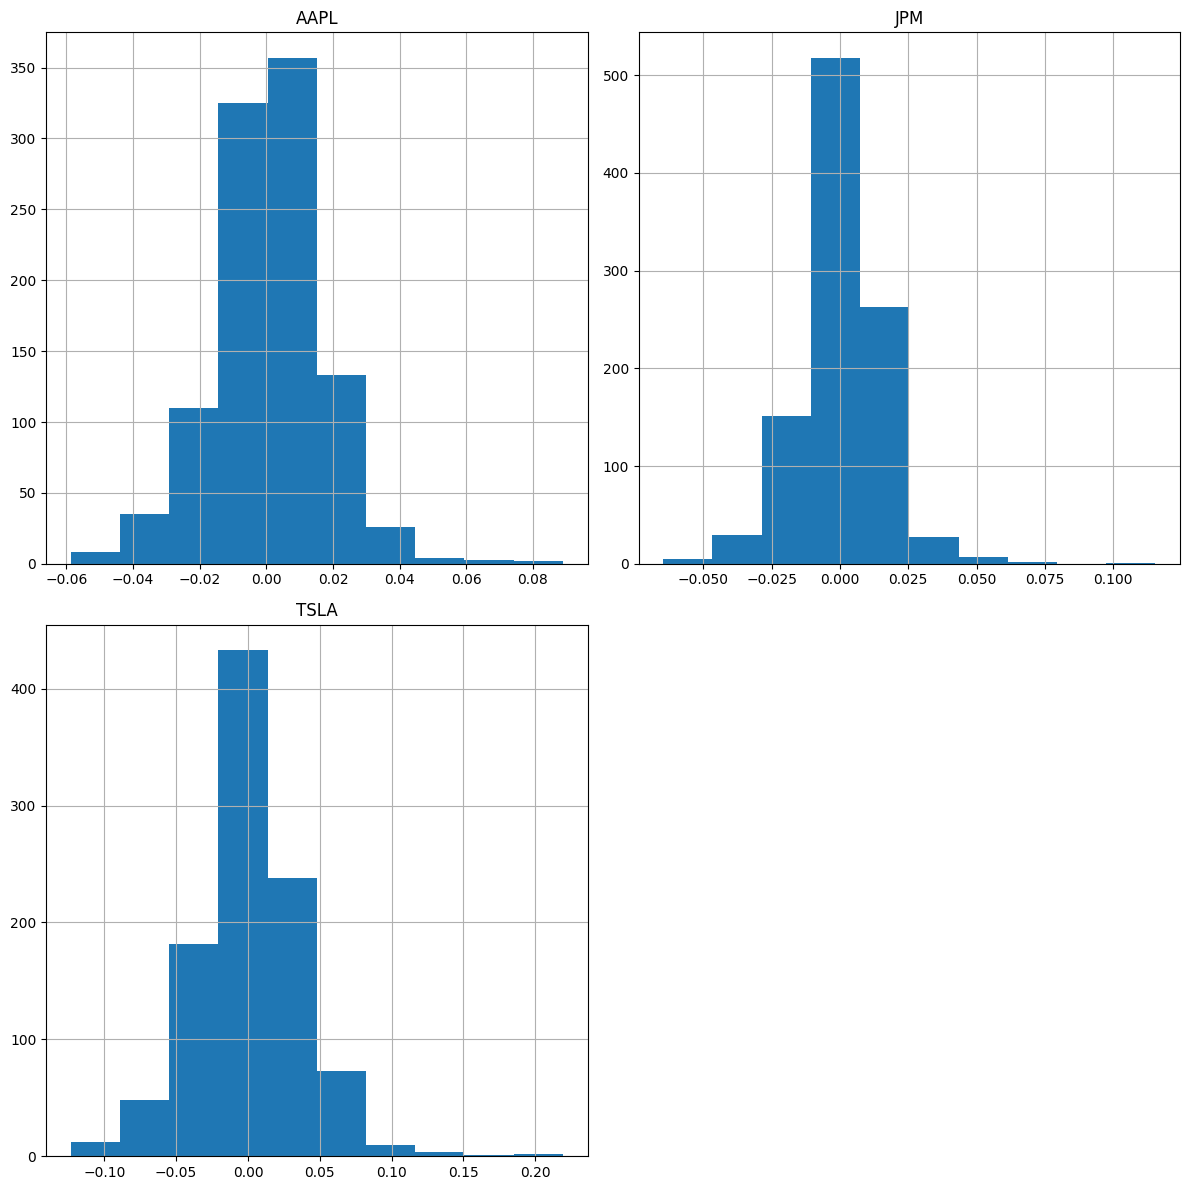

In [39]:
plot_retornos(retornos)

In [ ]:
#Activo de mayor riesgo: TSLA. Se observa una mayor volatilidad reflejado en su desviación estándar. Además su Kurtosis es alta lo que indica mayor probabilidad de eventos extremos.
#¿ Algún activo presenta distribución de retornos no simétrica o con colas pesadas? Tesla presenta una asimetría positiva, lo que indica que tiene una cola más larga a la derecha. Además, su kurtosis es alta, lo que sugiere colas pesadas y una mayor probabilidad de eventos extremos en comparación con una distribución normal.
#¿ Qué diferencias observas entre TSLA y JPM respecto a riesgo? JPM es menos volátil que TESLA, reflejado en su menor desviación estándar. Aún así, JPM presenta Kurtosis casi del doble que TESLA, lo que sugiere que JPM tiene una mayor probabilidad de eventos extremos en comparación con TESLA. Esto podría indicar que aunque JPM es menos volátil, tiene un riesgo de eventos extremos más alto que TESLA.  